In [2]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3


In [ ]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 이 셀 하나로 오늘 쓸 데이터가 모두 준비됩니다.
# (실제 현장처럼 '텍스트·날짜 오염'을 일부러 심어 둡니다)
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers) -------------------------------------------------
n_customers = 200
last_names = ["김", "이", "박", "최", "정", "강", "조", "윤", "장", "임"]
first_names = ["민준", "서연", "도윤", "지우", "하준", "서윤", "예준", "지유", "주원", "지호"]
names = [np.random.choice(last_names) + np.random.choice(first_names) for _ in range(n_customers)]
# 이름 일부에 앞뒤 공백 오염
for i in np.random.choice(n_customers, 15, replace=False):
    names[i] = "  " + names[i] + " "

# 이메일: 대소문자 + 앞뒤 공백 오염
domains = ["gmail.com", "naver.com", "MODUMARKET.com", "daum.net", "kakao.com"]
emails = []
for i in range(n_customers):
    e = f"user{i+1:03d}@{np.random.choice(domains)}"
    r = np.random.random()
    if r < 0.20:
        e = e.upper()              # 전체 대문자
    elif r < 0.35:
        e = "  " + e + " "         # 앞뒤 공백
    emails.append(e)

# 전화번호: 네 가지 형식 혼재
def make_phone(i):
    mid, end = np.random.randint(1000, 9999), np.random.randint(1000, 9999)
    fmt = i % 4
    if fmt == 0:
        return f"010-{mid}-{end}"
    if fmt == 1:
        return f"010{mid}{end}"
    if fmt == 2:
        return f"010.{mid}.{end}"
    return f"+82 10 {mid} {end}"
phones = [make_phone(i) for i in range(n_customers)]

# 지역: 표기 혼재(공백·영문)
region = np.random.choice(
    ["서울", " 서울 ", "Seoul", "경기", "부산", "인천", "대구"],
    n_customers, p=[0.30, 0.05, 0.05, 0.25, 0.15, 0.10, 0.10])

# 가입일: 네 가지 날짜 포맷 혼재(문자열로 저장)
signup_base = pd.to_datetime("2024-01-01") + pd.to_timedelta(np.random.randint(0, 365, n_customers), unit="D")
signup = []
for i, d in enumerate(signup_base):
    f = i % 4
    if f == 0:
        signup.append(d.strftime("%Y-%m-%d"))
    elif f == 1:
        signup.append(d.strftime("%Y/%m/%d"))
    elif f == 2:
        signup.append(d.strftime("%Y.%m.%d"))
    else:
        signup.append(d.strftime("%Y%m%d"))

customers = pd.DataFrame({
    "customer_id": [f"C{i+1:04d}" for i in range(n_customers)],
    "name": names,
    "email": emails,
    "phone": phones,
    "region": region,
    "signup_date": signup,
})

# 2) 주문(orders) ----------------------------------------------------
catalog = [("무선 이어폰", "P-1001", 89000), ("블루투스 스피커", "P-1002", 49000),
           ("노트북 거치대", "P-1003", 29000), ("기계식 키보드", "P-1004", 119000),
           ("USB-C 충전기", "P-1005", 19000), ("보조배터리", "P-1006", 39000),
           ("스마트워치", "P-1007", 159000), ("액션캠", "P-1008", 229000)]
n_orders = 2000
pick = np.random.randint(0, len(catalog), n_orders)

product_name, amount = [], []
for j in pick:
    name, codeid, price = catalog[j]
    label = f"{name} ({codeid})"
    r = np.random.random()
    if r < 0.18:
        label = "  " + label + "  "        # 앞뒤 공백
    elif r < 0.30:
        label = label.replace(" ", "  ")    # 단어 사이 이중 공백
    product_name.append(label)
    amount.append(price * np.random.choice([1, 1, 1, 2, 3]))

coupon = np.random.choice(
    ["SALE2025", "WELCOME10", "VIP-2025", "summer25", "FREESHIP", ""],
    n_orders, p=[0.18, 0.15, 0.10, 0.10, 0.07, 0.40])

channel = np.random.choice(["web", "app", "app ", "APP"], n_orders, p=[0.45, 0.45, 0.05, 0.05])

# 주문 일시: 두 가지 포맷 혼재 + 소수의 오류값
dt_base = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 90 * 24 * 3600, n_orders), unit="s")
order_datetime = []
for i, d in enumerate(dt_base):
    if i % 2 == 0:
        order_datetime.append(d.strftime("%Y-%m-%d %H:%M:%S"))
    else:
        order_datetime.append(d.strftime("%Y/%m/%d %H:%M:%S"))
# 오류값 심기: 파싱 불가능한 문자열 12건
for i in np.random.choice(n_orders, 12, replace=False):
    order_datetime[i] = np.random.choice(["처리중", "-", "unknown"])

orders = pd.DataFrame({
    "order_id": [f"O{i+1:05d}" for i in range(n_orders)],
    "customer_id": np.random.choice(customers["customer_id"], n_orders),
    "product_name": product_name,
    "amount": amount,
    "coupon": coupon,
    "channel": channel,
    "order_datetime": order_datetime,
})

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| orders:", orders.shape)

customers.head(6)

모두마켓 데이터 생성 완료
customers: (200, 6) | orders: (2000, 7)
  customer_id name                 email             phone region signup_date
0       C0001  조지우     user001@daum.net      010-8973-9577     경기  2024-04-27
1       C0002  윤하준    user002@gmail.com        01090709666     서울  2024/09/26
2       C0003  조지호     USER003@NAVER.COM     010.9609.7490     서울  2024.03.20
3       C0004  박예준     USER004@KAKAO.COM  +82 10 4600 7783     인천    20240402
4       C0005  윤하준     USER005@KAKAO.COM     010-5971-2205     대구  2024-09-22
5       C0006  최지유     user006@kakao.com       01029906299     부산  2024/11/27


In [11]:
orders.head(6)

,order_id,customer_id,product_name,amount,coupon,channel,order_datetime
0,O00001,C0131,무선 이어폰 (P-1001),89000,FREESHIP,app,2025-01-01 23:12:56
1,O00002,C0094,USB-C 충전기 (P-1005),57000,WELCOME10,web,2025/01/25 12:15:09
2,O00003,C0008,기계식 키보드 (P-1004),357000,,web,2025-01-31 14:14:25
3,O00004,C0086,블루투스 스피커 (P-1002),147000,,app,2025/03/30 02:12:54
4,O00005,C0089,무선 이어폰 (P-1001),89000,,web,2025-02-18 23:06:24
5,O00006,C0138,보조배터리 (P-1006),78000,WELCOME10,web,2025/02/18 07:41:05


In [21]:
orders["coupon"].value_counts()

coupon
             752
SALE2025     372
WELCOME10    308
summer25     222
VIP-2025     202
FREESHIP     144
Name: count, dtype: int64

In [23]:
# 예제: 변환 전 — order_datetime은 그냥 문자열(object)
print("dtype:", orders["order_datetime"].dtype)   # object = 문자열
print(orders["order_datetime"].head(6).tolist())

# 이 상태에서는 '시간 차이' 같은 계산이 불가능합니다.
print("\n'문자열'이라 정렬해도 날짜 순서가 보장되지 않습니다.")

dtype: str
['2025-01-01 23:12:56', '2025/01/25 12:15:09', '2025-01-31 14:14:25', '2025/03/30 02:12:54', '2025-02-18 23:06:24', '2025/02/18 07:41:05']

'문자열'이라 정렬해도 날짜 순서가 보장되지 않습니다.


In [24]:
# 예제: format='mixed' + errors='coerce'로 안전하게 변환
orders["order_dt"] = pd.to_datetime(
    orders["order_datetime"],
    format="mixed",        # 행마다 다른 형식을 각자 추론
    errors="coerce",       # 변환 못 하면 NaT(결측 날짜)
)

print("변환 후 dtype:", orders["order_dt"].dtype)   # datetime64[ns]
print("변환 실패(NaT) 건수:", orders["order_dt"].isna().sum())   # 오류값 12건
print(orders[["order_datetime", "order_dt"]].head(6))

변환 후 dtype: datetime64[us]
변환 실패(NaT) 건수: 12
        order_datetime            order_dt
0  2025-01-01 23:12:56 2025-01-01 23:12:56
1  2025/01/25 12:15:09 2025-01-25 12:15:09
2  2025-01-31 14:14:25 2025-01-31 14:14:25
3  2025/03/30 02:12:54 2025-03-30 02:12:54
4  2025-02-18 23:06:24 2025-02-18 23:06:24
5  2025/02/18 07:41:05 2025-02-18 07:41:05


In [31]:
# 예제: 구분자 통일 후 format 지정하기 (정제 → 파싱 연결)
# signup_date는 2024-03-15 / 2024/03/15 / 2024.03.15 / 20240315 가 섞여 있음
# 1단계: 정규식으로 구분자(- / .)를 모두 제거 → 'YYYYMMDD' 8자리로 통일 (Part 1~3 복습!)
digits_only = customers["signup_date"].str.replace(r"[^0-9]", "", regex=True)

# 2단계: 형식을 명시해 파싱 (가장 정확)
customers["signup_dt"] = pd.to_datetime(digits_only, format="%Y%m%d", errors="coerce")

print(customers[["signup_date", "signup_dt"]].head(6))
print("\n변환 실패 건수:", customers["signup_dt"].isna().sum())

print(customers["signup_dt"])

  signup_date  signup_dt
0  2024-04-27 2024-04-27
1  2024/09/26 2024-09-26
2  2024.03.20 2024-03-20
3    20240402 2024-04-02
4  2024-09-22 2024-09-22
5  2024/11/27 2024-11-27

변환 실패 건수: 0
0     2024-04-27
1     2024-09-26
2     2024-03-20
3     2024-04-02
4     2024-09-22
         ...    
195   2024-05-23
196   2024-04-15
197   2024-06-06
198   2024-05-25
199   2024-01-02
Name: signup_dt, Length: 200, dtype: datetime64[us]


In [34]:
# 스스로 해보자! (4)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) 기간 확인
print("가장 이른 주문:", orders["order_dt"].min())   # min
print("가장 늦은 주문:", orders["order_dt"].max())   # max

# 2) 파싱 실패 행의 원본 보기
failed = orders[orders["order_dt"].isna()]            # isna
print("\n",failed["order_datetime"].value_counts())

가장 이른 주문: 2025-01-01 00:36:15
가장 늦은 주문: 2025-03-31 23:20:27

 order_datetime
-          4
처리중        4
unknown    4
Name: count, dtype: int64


In [36]:
# 예제: 날짜에서 부품 꺼내 새 컬럼 만들기
valid = orders.dropna(subset=["order_dt"]).copy()   # NaT(파싱 실패) 제외

print(valid)

valid["year"] = valid["order_dt"].dt.year
valid["month"] = valid["order_dt"].dt.month
valid["hour"] = valid["order_dt"].dt.hour
valid["dow_num"] = valid["order_dt"].dt.dayofweek      # 0=월 ... 6=일
valid["dow_name"] = valid["order_dt"].dt.day_name()    # 영문 요일 이름

print(valid[["order_dt", "year", "month", "hour", "dow_num", "dow_name"]].head())

     order_id customer_id           product_name  amount     coupon channel  \
0      O00001       C0131      무선 이어폰 (P-1001)     89000   FREESHIP     app   
1      O00002       C0094     USB-C 충전기 (P-1005)   57000  WELCOME10     web   
2      O00003       C0008       기계식 키보드 (P-1004)  357000                web   
3      O00004       C0086    블루투스 스피커 (P-1002)    147000                app   
4      O00005       C0089        무선 이어폰 (P-1001)   89000                web   
...       ...         ...                    ...     ...        ...     ...   
1995   O01996       C0009      블루투스 스피커 (P-1002)   49000                web   
1996   O01997       C0078      무선  이어폰  (P-1001)  178000                web   
1997   O01998       C0014         액션캠 (P-1008)    687000   summer25     web   
1998   O01999       C0154         스마트워치 (P-1007)  159000  WELCOME10     web   
1999   O02000       C0113         보조배터리 (P-1006)   78000                app   

           order_datetime            oders_dt      

In [37]:
# 예제: 부품 + groupby = '요일별 평균 매출' (D+004 복습과 결합)
dow_sales = valid.groupby("dow_name")["amount"].mean()

# 요일 순서를 월→일로 정렬 (영문 이름 순서 지정)
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = dow_sales.reindex(order_days)

print("[요일별 평균 주문 금액]")
print(dow_sales.round(0))

[요일별 평균 주문 금액]
dow_name
Monday       162151.0
Tuesday      141141.0
Wednesday    137615.0
Thursday     157082.0
Friday       156325.0
Saturday     135774.0
Sunday       130071.0
Name: amount, dtype: float64


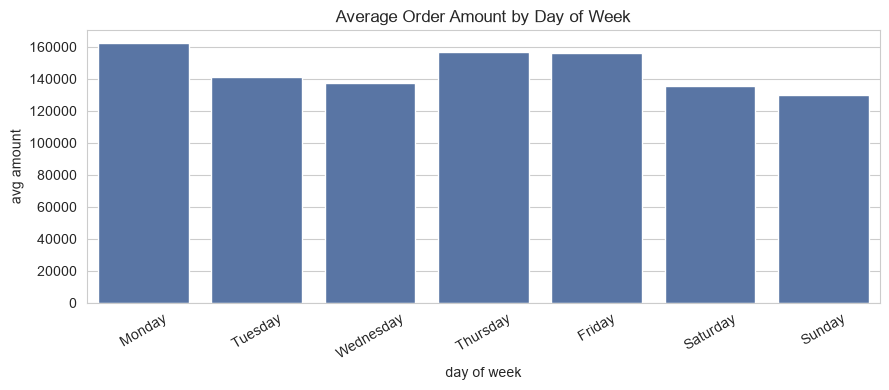

In [38]:
# [도식] 요일별 평균 매출 막대그래프 — 부품이 곧 인사이트가 된다
plt.figure(figsize=(9, 4))
sns.barplot(x=dow_sales.index, y=dow_sales.values, color="#4C72B0")
plt.title("Average Order Amount by Day of Week")
plt.xlabel("day of week"); plt.ylabel("avg amount")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

In [44]:
# 스스로 해보자! (5)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) 시간대별 주문 건수
print(valid["hour"].value_counts().sort_index())              # value_counts

# 2) 주말 주문 비율
weekend = valid[valid["dow_num"] >= 5]               # >= 5 (토=5, 일=6)
print("주말 주문 비율:", round(len(weekend) / len(valid) * 100, 1), "%")

hour
0      87
1      85
2      73
3      80
4      94
5     103
6      89
7      74
8      90
9      64
10     79
11     91
12     82
13     77
14     78
15     91
16    108
17     76
18     72
19     84
20     88
21     69
22     75
23     79
Name: count, dtype: int64
주말 주문 비율: 27.5 %


In [47]:
# 예제: 일별 매출 합계 (resample 'D')
ts = valid.set_index("order_dt").sort_index()   # 날짜를 인덱스로 + 시간순 정렬

print(ts)

daily_sales = ts["amount"].resample("D").sum()   # 하루 단위 합계
print("일별 매출 (앞 7일):")
print(daily_sales.head(7))
print("\n총 일수:", len(daily_sales))

                    order_id customer_id           product_name  amount  \
order_dt                                                                  
2025-01-01 00:36:15   O01905       C0124         액션캠 (P-1008)    229000   
2025-01-01 00:59:59   O01499       C0184     기계식  키보드  (P-1004)  119000   
2025-01-01 02:29:41   O00991       C0126      블루투스 스피커 (P-1002)   98000   
2025-01-01 04:16:16   O01096       C0124      블루투스 스피커 (P-1002)   98000   
2025-01-01 04:58:23   O00796       C0138    블루투스 스피커 (P-1002)     49000   
...                      ...         ...                    ...     ...   
2025-03-31 15:51:09   O01939       C0048       기계식 키보드 (P-1004)  119000   
2025-03-31 16:04:27   O00370       C0030         스마트워치 (P-1007)  159000   
2025-03-31 17:23:19   O00871       C0194      블루투스 스피커 (P-1002)   49000   
2025-03-31 17:32:11   O00755       C0189         스마트워치 (P-1007)  159000   
2025-03-31 23:20:27   O01179       C0028           액션캠 (P-1008)  229000   

                       c

In [ ]:
# 예제: 이동평균(rolling) — 들쭉날쭉한 일 매출을 7일 평균으로 부드럽게
daily_ma7 = daily_sales.rolling(7).mean()        # 최근 7일 이동평균

plt.figure(figsize=(11, 4))
plt.plot(daily_sales.index, daily_sales.values, alpha=0.4, label="Daily")
plt.plot(daily_ma7.index, daily_ma7.values, color="#C44E52", linewidth=2, label="7-day Moving Avg")
plt.title("Daily Sales and 7-day Moving Average")
plt.xlabel("date"); plt.ylabel("sales")
plt.legend()
plt.tight_layout(); plt.show()

In [ ]:
# 예제: 주 단위로 자를 바꿔보기 (resample 'W')
weekly_sales = ts["amount"].resample("W").sum()
print("[주별 매출]")
print(weekly_sales)

In [ ]:
# 스스로 해보자! (6)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) 시간대별 주문 건수
# hourly = ts["amount"].resample("___").count()    # 힌트: "h"
# print(hourly.head(24))

# 2) 3일 이동평균 vs 7일 이동평균
# ma3 = daily_sales.rolling(___).mean()            # 힌트: 3
# print(pd.DataFrame({"daily": daily_sales, "ma3": ma3, "ma7": daily_ma7}).head(10))

In [ ]:
# 웹 서버 접속 로그 생성 (가상) — 한 줄이 통째로 문자열
np.random.seed(7)
n_logs = 1500
ips = [f"203.0.113.{k}" for k in range(1, 60)] + [f"198.51.100.{k}" for k in range(1, 60)]
paths = ["/", "/products", "/products/123", "/products/456", "/cart",
         "/checkout", "/login", "/search", "/api/orders"]
methods = ["GET", "GET", "GET", "POST"]
statuses = [200, 200, 200, 200, 200, 404, 500, 301]

# 시각: 7일치, 초 단위로 무작위 발생 후 정렬
log_times = pd.to_datetime("2025-03-01") + pd.to_timedelta(
    np.sort(np.random.randint(0, 7 * 24 * 3600, n_logs)), unit="s")

lines = []
for i in range(n_logs):
    ip = np.random.choice(ips)
    ts_str = log_times[i].strftime("%d/%b/%Y:%H:%M:%S")   # 12/Jan/2025:10:15:32
    m = np.random.choice(methods)
    p = np.random.choice(paths)
    st = np.random.choice(statuses)
    sz = np.random.randint(200, 5000)
    lines.append(f'{ip} - - [{ts_str}] "{m} {p} HTTP/1.1" {st} {sz}')

web_logs = pd.DataFrame({"raw": lines})
print("웹 로그 생성 완료:", web_logs.shape)
print("\n[원본 로그 한 줄은 이렇게 생겼습니다]")
for line in web_logs["raw"].head(3):
    print(line)

In [ ]:
# 시나리오 1 — 정규식으로 6개 필드를 한 번에 추출
pattern = (
    r"(?P<ip>\d+\.\d+\.\d+\.\d+)"        # IP: 숫자.숫자.숫자.숫자
    r" - - \["                            # 고정 구분 부분
    r"(?P<ts>[^\]]+)"                     # 시각: ] 가 아닌 글자들
    r"\] \""                              # ] 와 따옴표
    r"(?P<method>\w+) "                   # 방식: GET/POST
    r"(?P<path>\S+)"                      # 경로: 공백 아닌 글자들
    r"[^\"]*\" "                          # HTTP/1.1 부분 건너뛰기
    r"(?P<status>\d+) "                   # 상태 코드
    r"(?P<size>\d+)"                      # 응답 크기
)
logs = web_logs["raw"].str.extract(pattern)
print("추출된 표:", logs.shape)
print(logs.head())
print("\n추출 실패(어느 한 칸이라도 NaN) 행 수:", logs.isna().any(axis=1).sum())

In [ ]:
# 시나리오 2 — 타입 정리(날짜·숫자) + dt 부품
logs["ts"] = pd.to_datetime(logs["ts"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
logs["status"] = logs["status"].astype(int)
logs["size"] = logs["size"].astype(int)

# dt 부품: 시각(hour)과 요일
logs["hour"] = logs["ts"].dt.hour
logs["dow_name"] = logs["ts"].dt.day_name()

print("정리 후 자료형:")
print(logs.dtypes)
print()
print(logs[["ip", "ts", "method", "path", "status", "hour", "dow_name"]].head())

In [ ]:
# 시나리오 2 — 상태 코드·인기 경로 빠르게 집계
print("[상태 코드 분포]")
print(logs["status"].value_counts())

error_rate = (logs["status"] >= 400).mean() * 100   # 4xx·5xx 비율
print(f"\n오류 응답(4xx·5xx) 비율: {error_rate:.1f}%")

print("\n[요청이 많은 경로 TOP 5]")
print(logs["path"].value_counts().head())

In [ ]:
# 시나리오 3 — 시간대별 트래픽 (resample 'h')
log_ts = logs.dropna(subset=["ts"]).set_index("ts").sort_index()
hourly_traffic = log_ts["ip"].resample("h").count()    # 시간당 요청 수

plt.figure(figsize=(12, 4))
plt.plot(hourly_traffic.index, hourly_traffic.values, color="#4C72B0")
plt.title("Hourly Web Traffic (requests per hour)")
plt.xlabel("time"); plt.ylabel("requests")
plt.tight_layout(); plt.show()

print("가장 트래픽이 많았던 시간대 TOP 3:")
print(hourly_traffic.sort_values(ascending=False).head(3))

In [ ]:
# 코드 퀴즈 — 모범 답안
# 1) 정제(strip+lower) → 2) @ 뒤 도메인 추출 → 3) 조건 집계
clean = customers["email"].str.strip().str.lower()
domain = clean.str.split("@").str[1]
gmail_count = (domain == "gmail.com").sum()

print("gmail.com 고객 수:", gmail_count)